In [ ]:
import numpy as np

class ThuatToanKMeans:
    """
    Lớp triển khai thuật toán phân cụm K-Means từ đầu.
    Ưu tiên code rõ ràng, dễ hiểu và đặt tên bằng tiếng Việt.
    """
    def __init__(self, so_cum=3, so_lan_lap_toi_da=100):
        self.so_cum = so_cum
        self.so_lan_lap_toi_da = so_lan_lap_toi_da
        self.cac_tam_cum = []
        self.nhan_cum_cua_du_lieu = []

    def khoi_tao_tam_cum_ngau_nhien(self, du_lieu):
        """
        Chọn ngẫu nhiên các điểm trong tập dữ liệu ban đầu để làm tâm cụm.
        """
        so_luong_mau = du_lieu.shape[0]
        # Chọn ngẫu nhiên các chỉ số dòng không trùng lặp
        cac_chi_so_ngau_nhien = np.random.choice(so_luong_mau, self.so_cum, replace=False)
        tam_cum_ban_dau = du_lieu[cac_chi_so_ngau_nhien]
        return tam_cum_ban_dau

    def tinh_khoang_cach_euclid(self, diem_A, diem_B):
        """
        Tính khoảng cách hình học giữa hai điểm dữ liệu.
        """
        hieu_toa_do = diem_A - diem_B
        binh_phuong_hieu = hieu_toa_do ** 2
        tong_binh_phuong = np.sum(binh_phuong_hieu)
        return np.sqrt(tong_binh_phuong)

    def tim_tam_cum_gan_nhat(self, diem_du_lieu, cac_tam_cum):
        """
        Duyệt qua các tâm cụm để tìm xem tâm nào gần điểm dữ liệu này nhất.
        """
        khoang_cach_ngan_nhat = float('inf')
        chi_so_cum_tot_nhat = 0

        for chi_so_cum, tam_cum in enumerate(cac_tam_cum):
            khoang_cach = self.tinh_khoang_cach_euclid(diem_du_lieu, tam_cum)
            if khoang_cach < khoang_cach_ngan_nhat:
                khoang_cach_ngan_nhat = khoang_cach
                chi_so_cum_tot_nhat = chi_so_cum

        return chi_so_cum_tot_nhat

    def gan_cum_cho_tat_ca_du_lieu(self, du_lieu, cac_tam_cum):
        """
        Gán nhãn cụm cho toàn bộ các điểm dữ liệu hiện có.
        """
        danh_sach_nhan = []
        for diem in du_lieu:
            cum_gan_nhat = self.tim_tam_cum_gan_nhat(diem, cac_tam_cum)
            danh_sach_nhan.append(cum_gan_nhat)
        return np.array(danh_sach_nhan)

    def cap_nhat_lai_cac_tam_cum(self, du_lieu, nhan_cum):
        """
        Tính tọa độ mới của tâm cụm bằng trung bình cộng các điểm trong cụm đó.
        """
        cac_tam_cum_moi = []
        for chi_so_cum in range(self.so_cum):
            # Lọc ra những điểm dữ liệu đang thuộc về cụm này
            cac_diem_trong_cum = du_lieu[nhan_cum == chi_so_cum]

            # Nếu cụm có điểm, tính trung bình cộng; nếu trống, giữ nguyên tâm cũ
            if len(cac_diem_trong_cum) > 0:
                tam_cum_moi = np.mean(cac_diem_trong_cum, axis=0)
                cac_tam_cum_moi.append(tam_cum_moi)
            else:
                cac_tam_cum_moi.append(self.cac_tam_cum[chi_so_cum])

        return np.array(cac_tam_cum_moi)

    def huan_luyen(self, du_lieu):
        """
        Hàm thực hiện toàn bộ luồng chạy của thuật toán K-Means.
        """
        # Bước 1: Khởi tạo
        self.cac_tam_cum = self.khoi_tao_tam_cum_ngau_nhien(du_lieu)

        # Bước 2: Vòng lặp cập nhật
        for lan_lap in range(self.so_lan_lap_toi_da):
            nhan_cum_moi = self.gan_cum_cho_tat_ca_du_lieu(du_lieu, self.cac_tam_cum)
            cac_tam_cum_moi = self.cap_nhat_lai_cac_tam_cum(du_lieu, nhan_cum_moi)

            # Điều kiện dừng: Nếu các tâm cụm không còn di chuyển nữa
            if np.all(self.cac_tam_cum == cac_tam_cum_moi):
                print(f"Thuật toán dừng sớm tại vòng lặp thứ: {lan_lap + 1}")
                break

            self.cac_tam_cum = cac_tam_cum_moi
            self.nhan_cum_cua_du_lieu = nhan_cum_moi

        return self.nhan_cum_cua_du_lieu, self.cac_tam_cum


# --- ĐOẠN MÃ CHẠY THỬ NGHIỆM ---
if __name__ == "__main__":
    # Tạo 6 điểm dữ liệu mẫu dạng 2D chia làm 2 nhóm rõ rệt
    du_lieu_mo_phong = np.array([
        [1, 1], [1, 2], [2, 1],      # Cụm tọa độ thấp
        [10, 10], [10, 11], [11, 10] # Cụm tọa độ cao
    ])

    # Khởi tạo mô hình tìm 2 cụm
    bo_phan_cum = ThuatToanKMeans(so_cum=2, so_lan_lap_toi_da=50)
    nhan_du_lieu, cac_tam = bo_phan_cum.huan_luyen(du_lieu_mo_phong)

    print("\n--- KẾT QUẢ ---")
    print("Mỗi điểm thuộc về cụm nào:", nhan_du_lieu)
    print("Tọa độ các tâm cụm cuối cùng:\n", cac_tam)

Thuật toán dừng sớm tại vòng lặp thứ: 3

--- KẾT QUẢ ---
Mỗi điểm thuộc về cụm nào: [0 0 0 1 1 1]
Tọa độ các tâm cụm cuối cùng:
 [[ 1.33333333  1.33333333]
 [10.33333333 10.33333333]]



   MENU ỨNG DỤNG DEMO HỌC MÁY
1. Chạy mô phỏng thuật toán K-Means
2. Chạy mô phỏng thuật toán k-NN
3. Thoát chương trình

--- ĐANG CHẠY DEMO K-MEANS ---


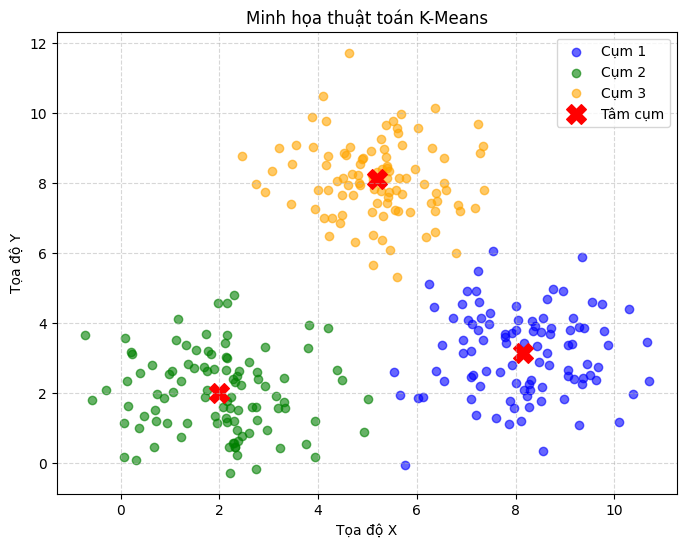


   MENU ỨNG DỤNG DEMO HỌC MÁY
1. Chạy mô phỏng thuật toán K-Means
2. Chạy mô phỏng thuật toán k-NN
3. Thoát chương trình

--- ĐANG CHẠY DEMO K-NN ---


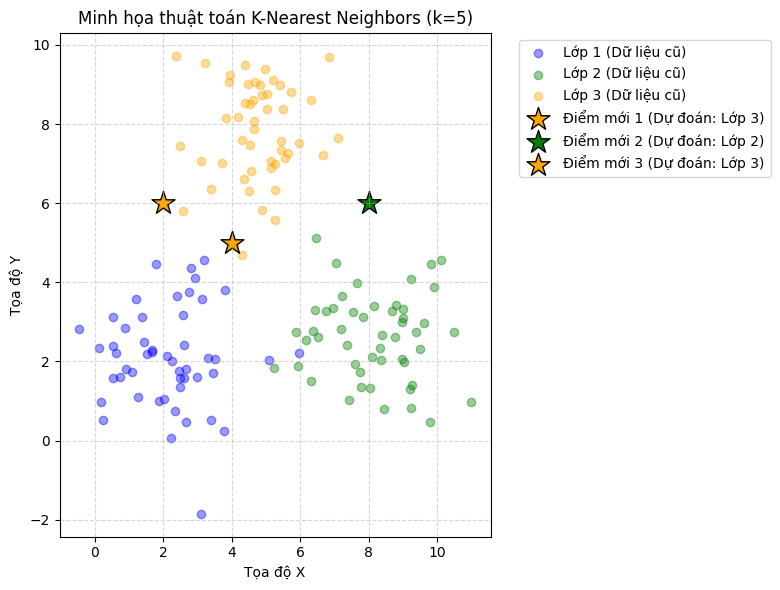


   MENU ỨNG DỤNG DEMO HỌC MÁY
1. Chạy mô phỏng thuật toán K-Means
2. Chạy mô phỏng thuật toán k-NN
3. Thoát chương trình


KeyboardInterrupt: Interrupted by user

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ==========================================
# PHẦN 1: CÁC LỚP THUẬT TOÁN (ĐÃ ĐƠN GIẢN HÓA)
# ==========================================

class ThuatToanKMeans:
    def __init__(self, so_cum=3, so_lan_lap_toi_da=100):
        self.so_cum = so_cum
        self.so_lan_lap_toi_da = so_lan_lap_toi_da
        self.cac_tam_cum = []

    def tinh_khoang_cach_euclid(self, diem_A, diem_B):
        return np.sqrt(np.sum((diem_A - diem_B) ** 2))

    def huan_luyen(self, du_lieu):
        # 1. Khởi tạo tâm cụm ngẫu nhiên
        so_luong_mau = du_lieu.shape[0]
        cac_chi_so = np.random.choice(so_luong_mau, self.so_cum, replace=False)
        self.cac_tam_cum = du_lieu[cac_chi_so]

        nhan_cum_cua_du_lieu = np.zeros(so_luong_mau)

        for lan_lap in range(self.so_lan_lap_toi_da):
            # 2. Gán điểm dữ liệu vào cụm gần nhất
            danh_sach_nhan = []
            for diem in du_lieu:
                khoang_cach_toi_cac_tam = [self.tinh_khoang_cach_euclid(diem, tam) for tam in self.cac_tam_cum]
                cum_gan_nhat = np.argmin(khoang_cach_toi_cac_tam)
                danh_sach_nhan.append(cum_gan_nhat)
            nhan_cum_cua_du_lieu = np.array(danh_sach_nhan)

            # 3. Cập nhật lại tọa độ tâm cụm
            cac_tam_cum_moi = []
            for chi_so_cum in range(self.so_cum):
                cac_diem_trong_cum = du_lieu[nhan_cum_cua_du_lieu == chi_so_cum]
                if len(cac_diem_trong_cum) > 0:
                    tam_cum_moi = np.mean(cac_diem_trong_cum, axis=0)
                    cac_tam_cum_moi.append(tam_cum_moi)
                else:
                    cac_tam_cum_moi.append(self.cac_tam_cum[chi_so_cum])
            cac_tam_cum_moi = np.array(cac_tam_cum_moi)

            # 4. Kiểm tra điều kiện dừng
            if np.all(self.cac_tam_cum == cac_tam_cum_moi):
                break
            self.cac_tam_cum = cac_tam_cum_moi

        return nhan_cum_cua_du_lieu, self.cac_tam_cum


class ThuatToanKNN:
    def __init__(self, so_lang_gieng=3):
        self.k = so_lang_gieng
        self.du_lieu_huan_luyen = None
        self.nhan_huan_luyen = None

    def huan_luyen(self, du_lieu, nhan):
        self.du_lieu_huan_luyen = du_lieu
        self.nhan_huan_luyen = nhan

    def tinh_khoang_cach_euclid(self, diem_A, diem_B):
        return np.sqrt(np.sum((diem_A - diem_B) ** 2))

    def du_doan_mot_diem(self, diem_kiem_tra):
        # Tính khoảng cách đến tất cả các điểm trong tập huấn luyện
        danh_sach_khoang_cach = []
        for diem_huan_luyen in self.du_lieu_huan_luyen:
            khoang_cach = self.tinh_khoang_cach_euclid(diem_kiem_tra, diem_huan_luyen)
            danh_sach_khoang_cach.append(khoang_cach)

        danh_sach_khoang_cach = np.array(danh_sach_khoang_cach)

        # Tìm k điểm gần nhất
        chi_so_k_diem_gan_nhat = np.argsort(danh_sach_khoang_cach)[:self.k]
        nhan_k_diem = self.nhan_huan_luyen[chi_so_k_diem_gan_nhat]

        # Bầu chọn đồng đều (lấy nhãn xuất hiện nhiều nhất)
        bo_dem = Counter(nhan_k_diem)
        nhan_pho_bien_nhat = bo_dem.most_common(1)[0][0]
        return nhan_pho_bien_nhat

    def du_doan(self, tap_du_lieu_kiem_tra):
        nhan_du_doan = []
        for diem in tap_du_lieu_kiem_tra:
            nhan = self.du_doan_mot_diem(diem)
            nhan_du_doan.append(nhan)
        return np.array(nhan_du_doan)


# ==========================================
# PHẦN 2: CÁC HÀM TIỆN ÍCH DÀNH CHO ỨNG DỤNG DEMO
# ==========================================

def tao_du_lieu_gia_lap(so_luong_mau=300, so_cum=3):
    """
    Tạo một tập dữ liệu giả lập gồm nhiều cụm phân tán để thử nghiệm thuật toán.
    Sử dụng numpy.random.randn để sinh tọa độ ngẫu nhiên xung quanh các tâm định trước.
    """
    du_lieu = []
    nhan_thuc_te = []

    # Định nghĩa 3 tâm cụm cách xa nhau
    cac_tam_mau = [[2, 2], [8, 3], [5, 8]]

    so_mau_moi_cum = so_luong_mau // so_cum
    for i, tam in enumerate(cac_tam_mau):
        # Sinh ngẫu nhiên dữ liệu xung quanh tâm hiện tại với độ lệch chuẩn là 1.2
        cum_du_lieu = np.random.randn(so_mau_moi_cum, 2) * 1.2 + tam
        du_lieu.extend(cum_du_lieu)
        nhan_thuc_te.extend([i] * so_mau_moi_cum)

    return np.array(du_lieu), np.array(nhan_thuc_te)


def chay_demo_kmeans():
    """
    Hàm chạy minh họa thuật toán K-Means và vẽ đồ thị trực quan.
    """
    print("\n--- ĐANG CHẠY DEMO K-MEANS ---")

    # 1. Chuẩn bị dữ liệu
    du_lieu, _ = tao_du_lieu_gia_lap(so_luong_mau=300, so_cum=3)

    # 2. Chạy thuật toán K-Means
    mo_hinh_kmeans = ThuatToanKMeans(so_cum=3, so_lan_lap_toi_da=50)
    nhan_du_doan, cac_tam_cum = mo_hinh_kmeans.huan_luyen(du_lieu)

    # 3. Trực quan hóa dữ liệu bằng Matplotlib
    plt.figure(figsize=(8, 6))
    cac_mau_sac = ['blue', 'green', 'orange']

    for chi_so_cum in range(3):
        # Lấy ra tọa độ các điểm thuộc về cụm hiện tại
        du_lieu_cua_cum = du_lieu[nhan_du_doan == chi_so_cum]
        plt.scatter(du_lieu_cua_cum[:, 0], du_lieu_cua_cum[:, 1],
                    c=cac_mau_sac[chi_so_cum], label=f'Cụm {chi_so_cum + 1}', alpha=0.6)

    # Vẽ các tâm cụm bằng dấu 'X' lớn màu đỏ
    plt.scatter(cac_tam_cum[:, 0], cac_tam_cum[:, 1],
                c='red', marker='X', s=200, label='Tâm cụm')

    plt.title("Minh họa thuật toán K-Means")
    plt.xlabel("Tọa độ X")
    plt.ylabel("Tọa độ Y")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


def chay_demo_knn():
    """
    Hàm chạy minh họa thuật toán K-NN và vẽ đồ thị trực quan.
    """
    print("\n--- ĐANG CHẠY DEMO K-NN ---")

    # 1. Chuẩn bị dữ liệu huấn luyện
    du_lieu_train, nhan_train = tao_du_lieu_gia_lap(so_luong_mau=150, so_cum=3)

    # 2. Tạo một vài điểm dữ liệu mới cần phân loại
    du_lieu_test = np.array([
        [4.0, 5.0],   # Nằm ở giữa đồ thị
        [8.0, 6.0],   # Nằm chếch phía trên phải
        [2.0, 6.0]    # Nằm chếch phía trên trái
    ])

    # 3. Chạy mô hình K-NN
    mo_hinh_knn = ThuatToanKNN(so_lang_gieng=5)
    mo_hinh_knn.huan_luyen(du_lieu_train, nhan_train)
    nhan_du_doan_test = mo_hinh_knn.du_doan(du_lieu_test)

    # 4. Trực quan hóa kết quả
    plt.figure(figsize=(8, 6))
    cac_mau_sac = ['blue', 'green', 'orange']

    # Vẽ tập dữ liệu huấn luyện bằng các chấm tròn
    for chi_so_lop in range(3):
        du_lieu_lop = du_lieu_train[nhan_train == chi_so_lop]
        plt.scatter(du_lieu_lop[:, 0], du_lieu_lop[:, 1],
                    c=cac_mau_sac[chi_so_lop], label=f'Lớp {chi_so_lop + 1} (Dữ liệu cũ)', alpha=0.4)

    # Vẽ các điểm test bằng dấu ngôi sao lớn có viền đen
    for i, diem in enumerate(du_lieu_test):
        mau_du_doan = cac_mau_sac[nhan_du_doan_test[i]]
        plt.scatter(diem[0], diem[1],
                    c=mau_du_doan, marker='*', s=300, edgecolor='black',
                    label=f'Điểm mới {i + 1} (Dự đoán: Lớp {nhan_du_doan_test[i] + 1})')

    plt.title("Minh họa thuật toán K-Nearest Neighbors (k=5)")
    plt.xlabel("Tọa độ X")
    plt.ylabel("Tọa độ Y")

    # Sắp xếp lại bảng chú thích cho gọn
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout() # Đảm bảo bảng chú thích không bị cắt lẹm
    plt.show()

# ==========================================
# PHẦN 3: MENU ĐIỀU KHUYỂN ỨNG DỤNG
# ==========================================
if __name__ == "__main__":
    while True:
        print("\n" + "="*40)
        print("   MENU ỨNG DỤNG DEMO HỌC MÁY")
        print("="*40)
        print("1. Chạy mô phỏng thuật toán K-Means")
        print("2. Chạy mô phỏng thuật toán k-NN")
        print("3. Thoát chương trình")

        lua_chon = input("Vui lòng nhập lựa chọn của bạn (1-3): ").strip()

        if lua_chon == '1':
            chay_demo_kmeans()
        elif lua_chon == '2':
            chay_demo_knn()
        elif lua_chon == '3':
            print("Đã thoát chương trình. Tạm biệt!")
            break
        else:
            print("Lựa chọn không hợp lệ, vui lòng thử lại!")